# Ladder episode analysis — who did a submission actually play, and how did it go?

Set `SUBMISSION_IDS` below (from `kaggle competitions submissions`) and run all
cells. Episodes and replays are fetched once and cached in `results/episodes/`;
opponent decks are extracted from the replays and classified with the same
decklist-only archetype features the QD search uses.

In [1]:
# --- config: which of our submissions to analyse -----------------------------
SUBMISSION_IDS = [54367885, 54266227, 54297327]

In [2]:
import sys, json
from pathlib import Path
from collections import Counter

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.deck import build_pool
from src.qd import deck_stats, evolution_depth, prize_liability
from scripts.ladder_episodes import (
    classify, fetch_episode_list, fetch_replay, replay_decks,
)
from scripts.run_eval import read_deck

pool = build_pool()
pd.set_option("display.width", 160)

## 1. Fetch episodes + opponent decks (cached)

In [3]:
rows = []
for sid in SUBMISSION_IDS:
    listing = fetch_episode_list(sid)
    teams = {t["id"]: t.get("teamName", "?") for t in listing.get("teams", [])}
    for ep in listing["episodes"]:
        if ep.get("state") != "COMPLETED":
            continue
        agents = ep["agents"]
        mine = next((a for a in agents if a.get("submissionId") == sid), None)
        opp = next((a for a in agents if a.get("submissionId") != sid), None)
        if mine is None or opp is None:
            continue
        replay = fetch_replay(ep["id"])
        decks = replay_decks(replay) if replay else None
        my_idx = mine.get("index", 0)
        rows.append({
            "sub": sid,
            "time": ep.get("endTime", ""),
            "reward": mine.get("reward"),
            "elo_before": mine.get("initialScore"),
            "elo_after": mine.get("updatedScore"),
            "opp_elo": opp.get("initialScore"),
            "opp_team": teams.get(opp.get("teamId"), "?"),
            "opp_sub": opp.get("submissionId"),
            "opp_deck": decks[1 - my_idx] if decks else None,
        })

df = pd.DataFrame(rows).sort_values(["sub", "time"]).reset_index(drop=True)
df["result"] = df["reward"].map({1: "W", -1: "L", 0: "T"})
df["opp_archetype"] = df["opp_deck"].map(
    lambda d: classify(d, pool) if d else "?")
print(f"{len(df)} completed episodes across {len(SUBMISSION_IDS)} submissions")
df.groupby("sub")["result"].value_counts().unstack(fill_value=0)

112 completed episodes across 3 submissions


result,L,T,W
sub,,,
54266227,34,0,21
54297327,26,0,21
54367885,4,1,5


## 2. Elo trajectory per submission

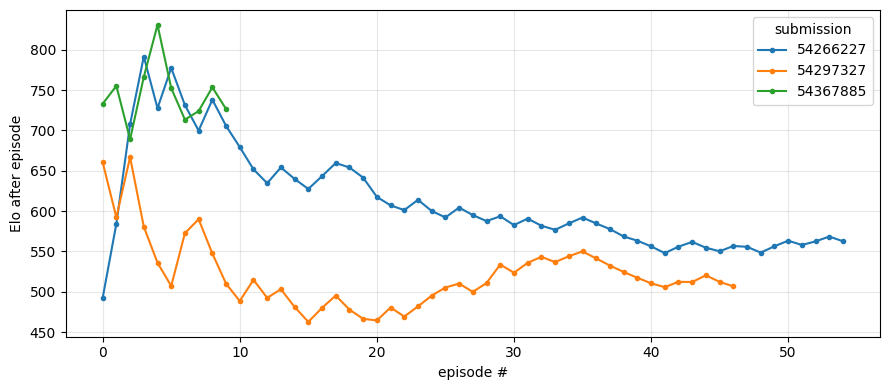

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for sid, g in df.groupby("sub"):
    g = g.reset_index(drop=True)
    ax.plot(g.index, g["elo_after"], marker="o", ms=3, label=str(sid))
ax.set_xlabel("episode #")
ax.set_ylabel("Elo after episode")
ax.legend(title="submission")
ax.grid(alpha=0.3)
plt.tight_layout()

## 3. Win rate by opponent Elo bracket

In [5]:
dec = df[df["reward"].isin([1, -1])].copy()
dec["bracket"] = pd.cut(dec["opp_elo"], [0, 450, 550, 650, 2000],
                        labels=["<450", "450-550", "550-650", "650+"])
(dec.groupby(["sub", "bracket"], observed=True)["reward"]
    .agg(games="count", winrate=lambda r: (r == 1).mean().round(2)))

games  winrate
sub      bracket                
54266227 450-550     13     0.54
         550-650     22     0.45
         650+        20     0.20
54297327 <450         8     0.88
         450-550     24     0.38
         550-650      9     0.44
         650+         6     0.17
54367885 <450         1     1.00
         650+         8     0.50

## 4. Wins / losses by real opponent archetype

In [6]:
dec["arch"] = dec["opp_archetype"].str.split(" ").str[0]
pivot = (dec.groupby(["arch"])["reward"]
         .agg(games="count", winrate=lambda r: round((r == 1).mean(), 2))
         .sort_values("games", ascending=False))
pivot

,games,winrate
arch,,
W/evo/mid,26,0.46
P/evo/1pz,20,0.50
F/evo/mid,13,0.15
G/evo/mid,12,0.67
G/evo/1pz,7,0.14
M/evo/mid,6,0.50
P/evo/mid,6,0.33
D/evo/1pz,5,0.40
R/evo/1pz,2,0.50


In [7]:
# every loss, hardest opponents first
cols = ["sub", "opp_team", "opp_elo", "opp_archetype"]
dec[dec["reward"] == -1].sort_values("opp_elo", ascending=False)[cols]

,sub,opp_team,opp_elo,opp_archetype
98,54297327,niyo,1003.713955,M/evo/1pz P14T33E13 c3
47,54266227,Shunji Minode,905.727869,D/evo/1pz P22T28E10 c3
18,54266227,yuziri,890.417065,P/evo/1pz P15T36E9 c1
104,54367885,shu8Cream,843.939015,F/evo/mid P14T31E15 c1
75,54297327,shige,839.439856,F/evo/mid P17T29E14 c1
...,...,...,...,...
64,54297327,yuhas0726,491.204180,W/evo/mid P22T27E11 c2
101,54297327,ML_Bear,490.338326,P/evo/1pz P19T33E8 c1
20,54266227,ミズゴロウ,479.177126,D/evo/1pz P18T22E20 c3
73,54297327,Phil Franco,477.825525,P/evo/mid P17T30E13 c1


## 5. The real ladder meta vs our held-out pool

Distinct opponent decks (deduped by opponent submission), composition and
evolution share, against `decklists/heldout/`.

In [8]:
seen = {}
for _, r in df.iterrows():
    if r["opp_deck"]:
        seen[r["opp_sub"]] = r["opp_deck"]
ladder_decks = list(seen.values())

def pool_stats(decks):
    comp = np.array([[deck_stats(d, pool)[k]
                      for k in ("pokemon", "trainer", "energy")] for d in decks])
    evo = np.array([evolution_depth(d, pool) for d in decks])
    return {
        "n": len(decks),
        "evo-deck share": round(float((evo > 0.25).mean()), 2),
        "P median": float(np.median(comp[:, 0])),
        "T median": float(np.median(comp[:, 1])),
        "E median": float(np.median(comp[:, 2])),
    }

heldout = [read_deck(p) for p in sorted((ROOT / "decklists/heldout").glob("*.csv"))]
pd.DataFrame({"ladder (real)": pool_stats(ladder_decks),
              "held-out (ours)": pool_stats(heldout)})

,ladder (real),held-out (ours)
n,110.00,30.0
evo-deck share,0.95,0.0
P median,16.00,12.0
T median,32.00,17.0
E median,13.00,31.0


In [9]:
# strongest distinct opponents -- candidates for a real-meta eval pool / anchors
opp_best = (df.dropna(subset=["opp_deck"])
            .sort_values("opp_elo", ascending=False)
            .drop_duplicates("opp_sub"))
opp_best[["opp_team", "opp_elo", "opp_archetype"]].head(20)

,opp_team,opp_elo,opp_archetype
98,niyo,1003.713955,M/evo/1pz P14T33E13 c3
47,Shunji Minode,905.727869,D/evo/1pz P22T28E10 c3
18,yuziri,890.417065,P/evo/1pz P15T36E9 c1
104,shu8Cream,843.939015,F/evo/mid P14T31E15 c1
75,shige,839.439856,F/evo/mid P17T29E14 c1
111,Handudu,821.161155,F/evo/mid P17T29E14 c1
22,[ODS] waniz,792.538337,G/evo/mid P16T36E8 c3
84,Mitudru Dutta,790.289610,P/evo/1pz P20T33E7 c5
7,surugawannoebi,782.708806,F/evo/1pz P19T33E8 c2
108,monaou,782.302056,P/evo/1pz P20T33E7 c2
